In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# Wstępna eksploracja danych

In [5]:
df = pd.read_csv('C:/Users/User/Documents/MCHTR/PML/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


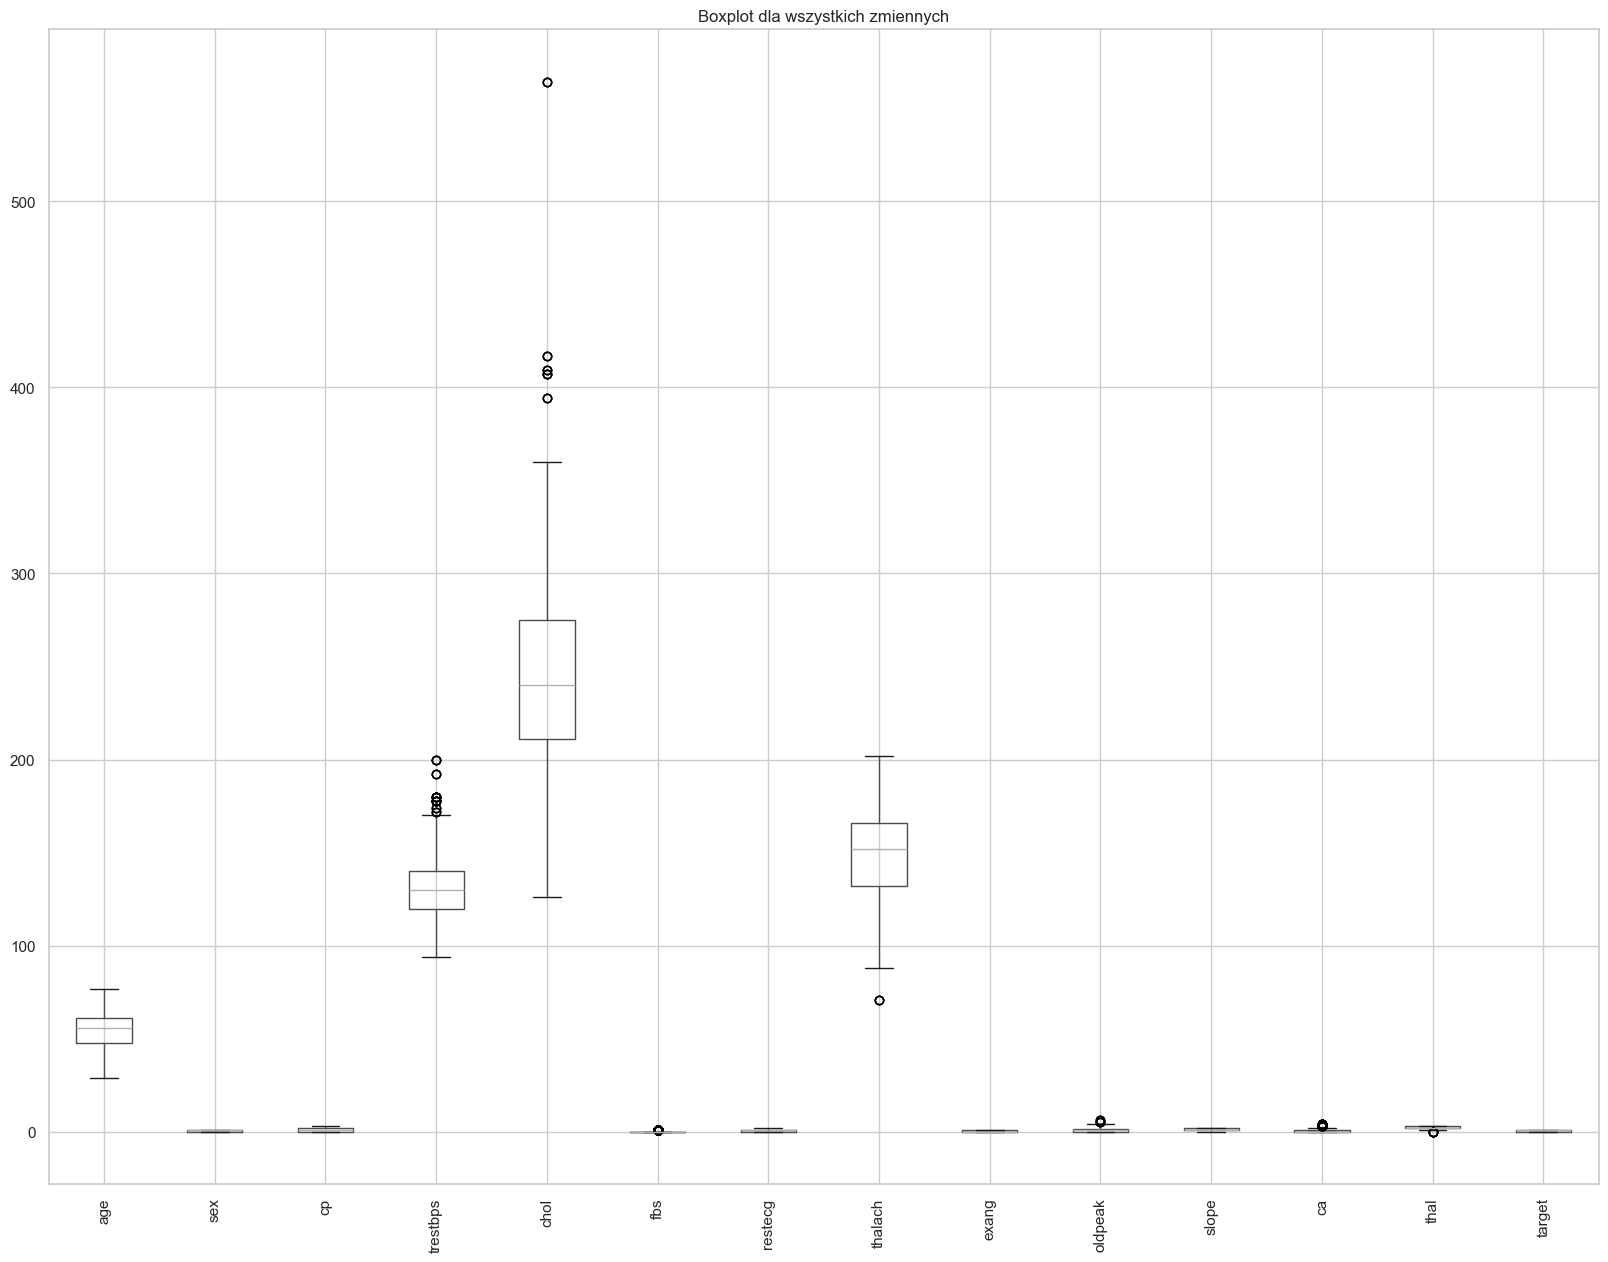

In [8]:
plt.figure(figsize=(20, 15))
df.boxplot()
plt.xticks(rotation=90)
plt.title("Boxplot dla wszystkich zmiennych")
plt.show()

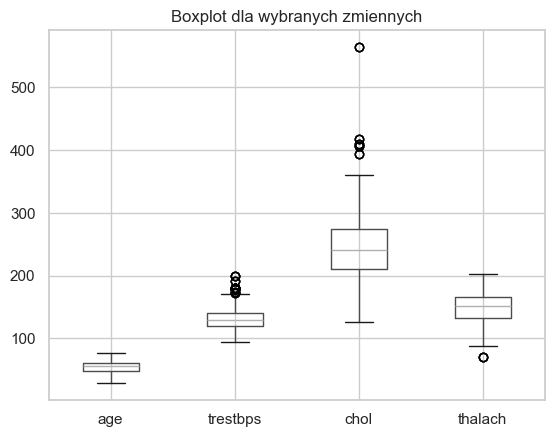

In [9]:
dfBP = df[["age","trestbps","chol","thalach"]]
dfBP.boxplot()
plt.title("Boxplot dla wybranych zmiennych")
plt.show()

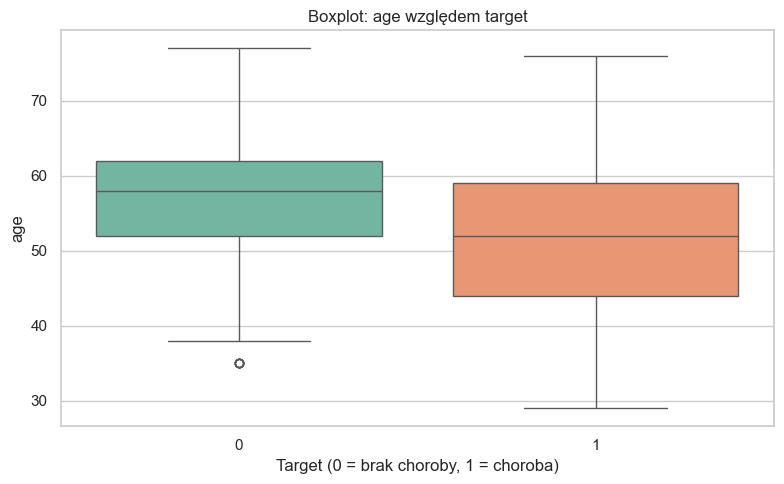

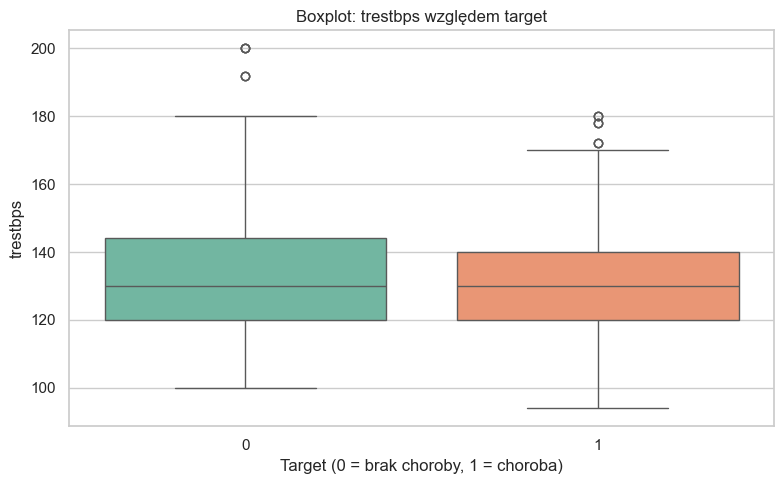

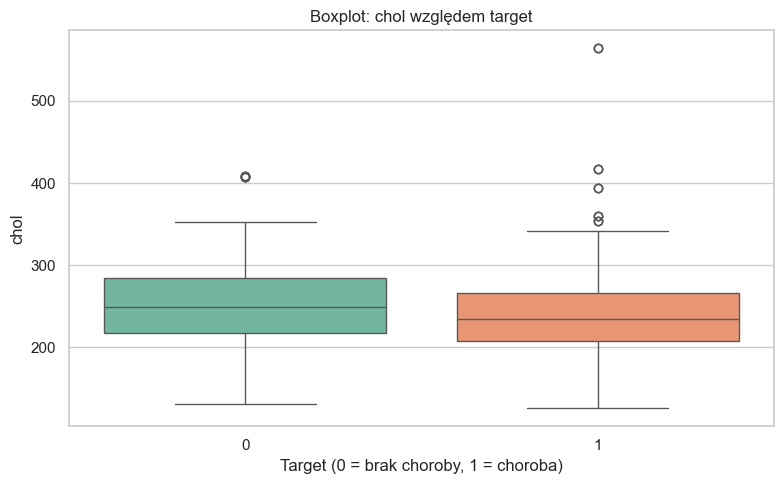

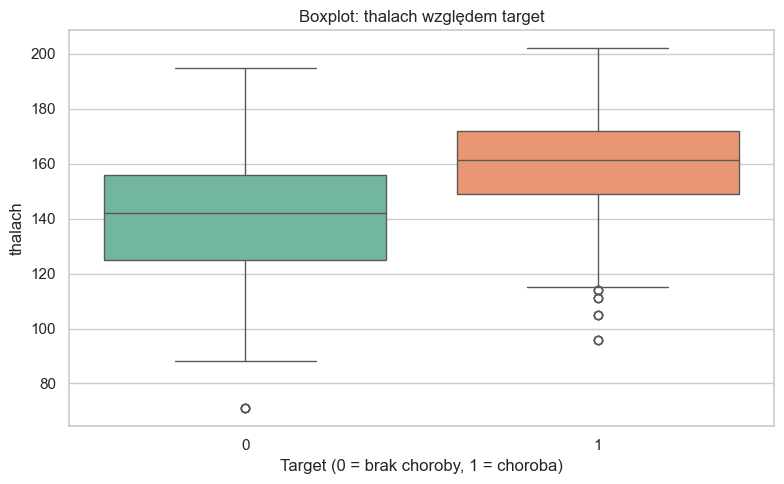

In [36]:
columns_to_plot = ["age", "trestbps", "chol", "thalach"]

for col in columns_to_plot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="target", y=col, hue="target", data=df, palette="Set2", dodge=False)
    plt.title(f'Boxplot: {col} względem target')
    plt.xlabel("Target (0 = brak choroby, 1 = choroba)")
    plt.ylabel(col)
    plt.legend([],[], frameon=False)  # Ukrycie legendy
    plt.tight_layout()
    plt.show()

# Macierz korelacji

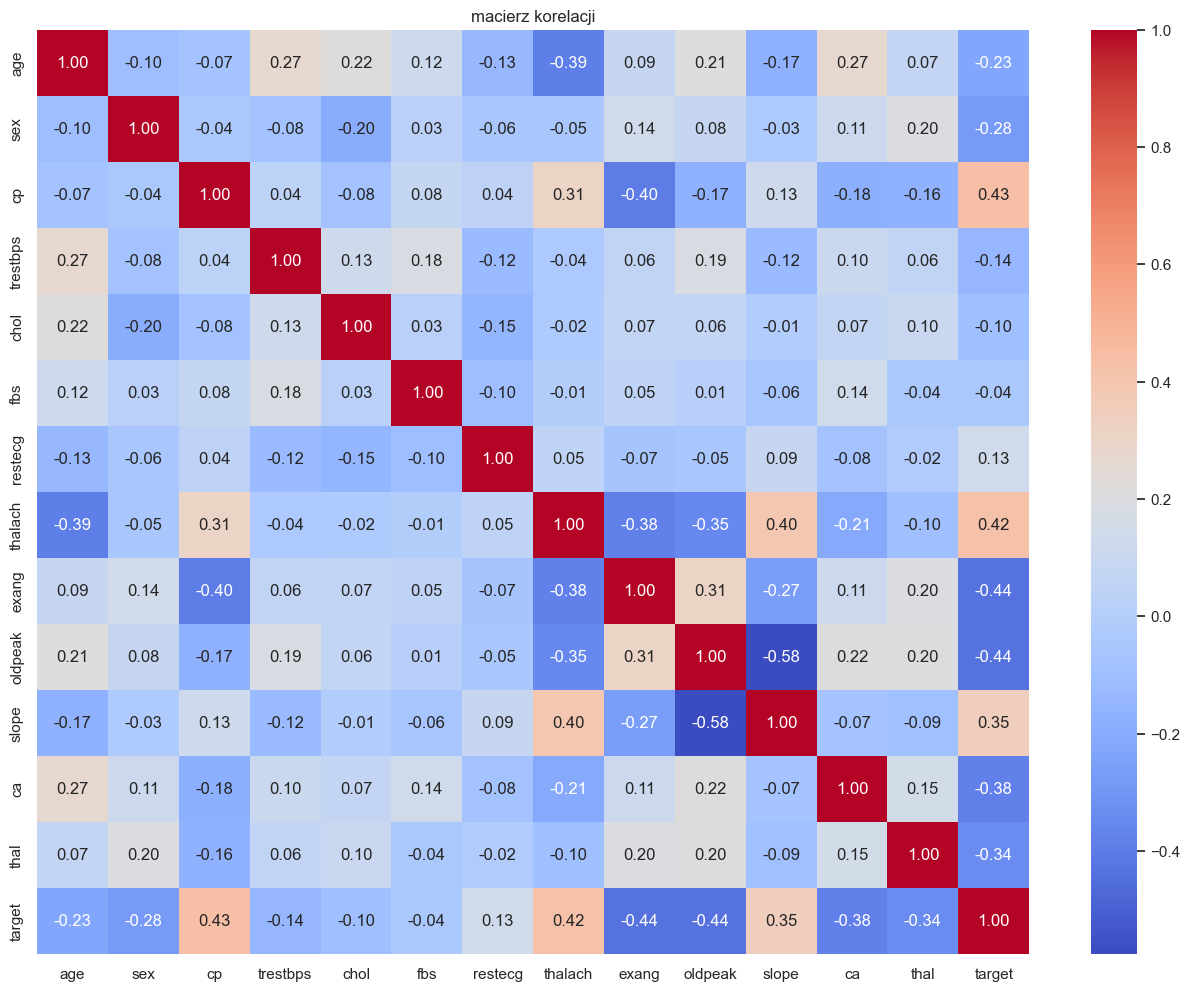

In [7]:
corr_matrix = df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("macierz korelacji")
plt.show()

In [8]:
strong_corr = corr_matrix[((corr_matrix > 0.7) | (corr_matrix < -0.7)) & (corr_matrix != 1.0)]
strong_corr.dropna(how="all", axis=0).dropna(how="all", axis=1)

""


# Macierz korelacji r Pearson > 0,4

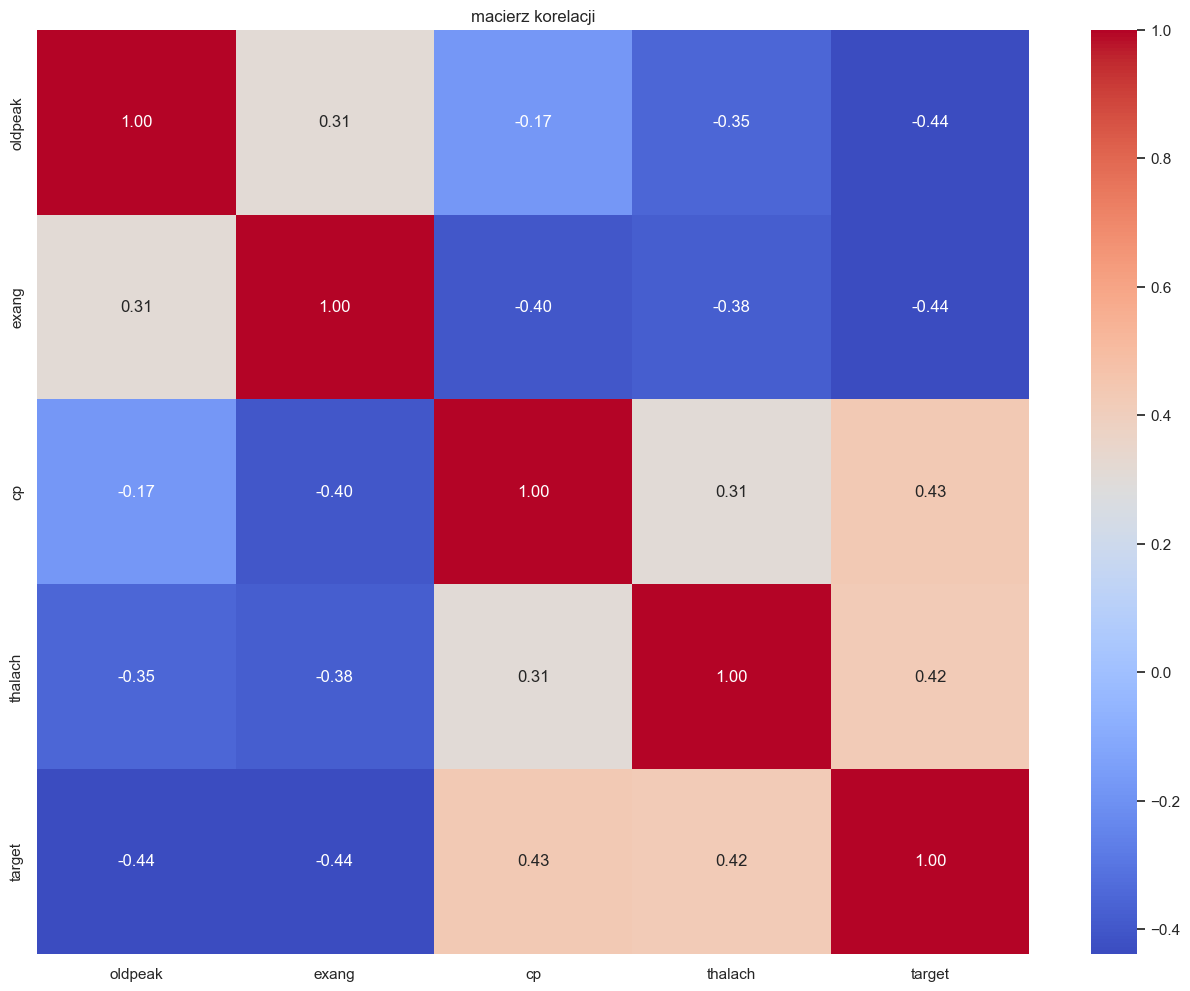

In [10]:
df2 = df[['oldpeak','exang','cp','thalach','target']]
df2.head()
corr_matrix_04 = df2.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix_04, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("macierz korelacji")
plt.show()

# Macierz korelarcji Spearmana

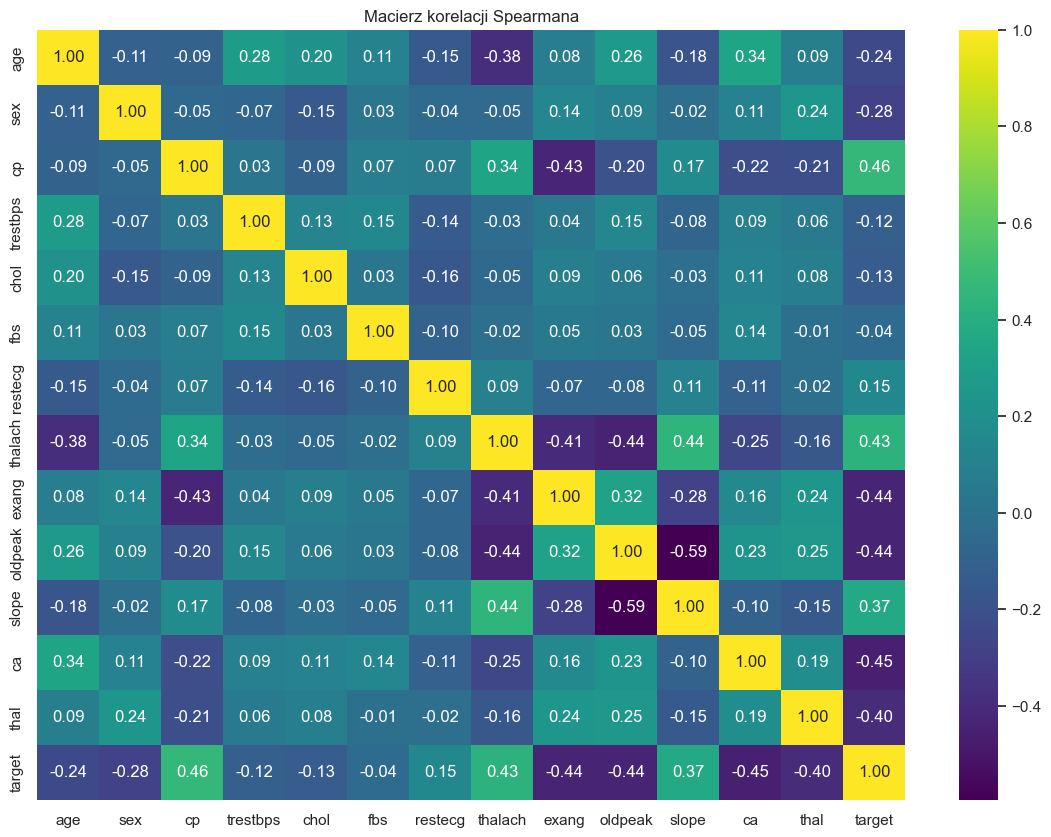

In [22]:
spearman_corr = df.corr(method='spearman')
plt.figure(figsize=(14, 10))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="viridis")
plt.title('Macierz korelacji Spearmana')
plt.show()